In [1]:
# === repo-root bootstrap ===
import os, sys
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

Repo root: /Users/henryzou/Documents/GitHub/OQPA


# How CSWAP-based QPA scales — classical vs. coherent

A companion to [`compare_classical_vs_cswap_pittsburgh.ipynb`](compare_classical_vs_cswap_pittsburgh.ipynb)
and Caio's [`swapnet_n3_compare_analysis.ipynb`](swapnet_n3_compare_analysis.ipynb). The comparison
notebook shows the two flavours are equivalent at `N=3, T=1`. **This** notebook answers: *as the
protocol grows, what does each flavour cost?* It is **fully local** (no QPU, no IBM account) and runs
in well under a minute.

Three flavours of the QPA logic:

| Flavour | # circuits to run | Routing mechanism | Cost driver |
|---|---|---|---|
| **Classical — unrolled** | `2^((N-1)/2 · T)` static circuits, post-selected | unconditional SWAP per enumerated path | **circuit count** (exponential) |
| **Classical — dynamic** | 1 circuit | `if_test` + conditional SWAP (mid-circuit measure + feed-forward) | real-time control latency, nested `if_test` |
| **Coherent — CSWAP** | 1 circuit | controlled-SWAP (Fredkin); deeper trials → multi-controlled | **gate count / depth** (multi-control blow-up) |

We sweep **`N` (registers) at `T=1`** — the regime of the standard workflow — and **`T` (trials) at
`N=3`** — Caio's regime — and measure qubit width, two-qubit-gate count, and two-qubit depth after
transpilation to a real heavy-hex coupling map (`FakeBrisbane`, offline).

> The coherent builder for `N>3` is a faithful **generalization** of Caio's `N=3` design (parallel
> Schur tests on the `(N-1)//2` front pairs, then an all-pass-controlled cyclic rotation). It is used
> here for **resource counting**; the fidelity-correct multi-pair coherent routing is still a research
> item, so this notebook reports *cost*, not fidelity, for `N>3`.

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import SwapGate
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
from core.circuit_factory import CircuitFactory
print("Imports loaded.")

Imports loaded.


## Builders — classical (unrolled & dynamic) and generalized coherent CSWAP

In [3]:
# ---------- Classical: unrolled (project standard) ----------
def build_unrolled(n, k, t):
    s = CircuitFactory.create_strategy("unrolled", k, t, n, no_reset=False)
    s.set_noise_strategy(None)
    return [d["circuit"] for d in s.build(0.0)]          # one circuit per path

# ---------- Classical: dynamic (if_test) ----------
def build_dynamic(n, k, t):
    s = CircuitFactory.create_strategy("dynamic", k, t, n)
    s.set_noise_strategy(None)
    return s.build(0.0)[0]["circuit"]                    # single dynamic circuit

# ---------- Coherent: generalized CSWAP (reduces to Caio's design at n=3) ----------
def _coherent_trial_gate(n, k):
    """Parallel Schur tests on the (n-1)//2 front pairs, then an all-pass-controlled cyclic
    rotation of all n registers (each elementary SWAP controlled on every pair's ancilla == 0)."""
    m = (n - 1) // 2
    qc = QuantumCircuit(m + n * k)
    anc = list(range(m))
    regs = [list(range(m + j * k, m + (j + 1) * k)) for j in range(n)]
    for p in range(m):                                   # swap tests
        a, rA, rB = anc[p], regs[2 * p], regs[2 * p + 1]
        qc.h(a)
        for i in range(k):
            qc.cswap(a, rA[i], rB[i])
        qc.h(a)
    for a in anc:                                        # rotate iff all tests passed (anc == 0)
        qc.x(a)
    for row in range(k):
        for j in range(n - 1, 0, -1):
            if m == 1:
                qc.cswap(anc[0], regs[j][row], regs[j - 1][row])
            else:
                qc.append(SwapGate().control(m), anc + [regs[j][row], regs[j - 1][row]])
    for a in anc:
        qc.x(a)
    return qc.to_gate(label=f"coh_trial_n{n}")

def build_coherent(n, k, t):
    m = (n - 1) // 2
    qr = [QuantumRegister(k, f"R{i + 1}") for i in range(n)]
    cr = ClassicalRegister(k, "readout")
    if t <= 0:
        qc = QuantumCircuit(*qr, cr); qc.measure(qr[n - 1], cr); return qc
    qa = [QuantumRegister(m, f"trial_a{s}") for s in range(t)]
    qc = QuantumCircuit(*qr, *qa, cr)
    tg = _coherent_trial_gate(n, k)
    data = [q for reg in qr for q in reg[:]]
    for step in range(t):
        anc_t = [qa[step][i] for i in range(m)]
        if step == 0:
            qc.append(tg, anc_t + data)
        else:
            prev = [qa[s][i] for s in range(step) for i in range(m)]
            qc.append(tg.control(num_ctrl_qubits=len(prev), ctrl_state="0" * len(prev)), prev + anc_t + data)
    qc.measure(qr[n - 1], cr)
    return qc

print("Builders defined.")

Builders defined.


## Configuration & resource metrics

`FakeBrisbane` (127-qubit heavy-hex) gives realistic ISA two-qubit counts offline. We do **not**
transpile the dynamic circuit (its nested `if_test` hits the opt-level≥2 transpiler bug, see project
memory); we report its *logical* control-flow footprint instead.

In [4]:
K = 2
N_VALUES = [3, 5, 7, 9, 11]      # register sweep at T=1
T_VALUES = [1, 2, 3, 4]          # trial sweep at N=3
backend = FakeBrisbane()
print(f"Backend: {backend.name} ({backend.num_qubits} qubits)")

def n2q(qc):  return sum(1 for ins in qc.data if len(ins.qubits) == 2)
def n3q(qc):  return sum(1 for ins in qc.data if len(ins.qubits) == 3)   # logical Fredkins/CSWAPs

def count_recursive(qc, name=None, nq=None):
    """Count ops matching name/qubit-count, descending into control-flow (if_else) blocks."""
    total = 0
    for ins in qc.data:
        op = ins.operation
        blocks = getattr(op, "blocks", None)
        if blocks:
            for blk in blocks:
                total += count_recursive(blk, name, nq)
            if name == op.name:
                total += 1
            continue
        if (name is None or op.name == name) and (nq is None or len(ins.qubits) == nq):
            total += 1
    return total
def isa(qc, opt=1):
    qt = transpile(qc, backend=backend, optimization_level=opt, seed_transpiler=0)
    return qt.num_qubits, qt.depth(lambda i: len(i.qubits) == 2), n2q(qt)

print("Metrics ready.")

Backend: fake_brisbane (127 qubits)
Metrics ready.


## Sweep 1 — registers `N` (T = 1), the standard-workflow regime

In [5]:
rows = []
for n in N_VALUES:
    paths = build_unrolled(n, K, 1)
    n_paths = len(paths)
    # classical unrolled: transpile every path, sum ISA 2Q gates (total hardware work)
    cl_2q_total, cl_2q_depth_max = 0, 0
    for qc in paths:
        _, d2q, g2q = isa(qc)
        cl_2q_total += g2q
        cl_2q_depth_max = max(cl_2q_depth_max, d2q)
    # coherent: single circuit
    coh = build_coherent(n, K, 1)
    coh_w = coh.num_qubits
    _, coh_d2q, coh_2q = isa(coh)
    rows.append({
        "N": n,
        "unrolled_circuits": n_paths,
        "unrolled_2Q_total": cl_2q_total,
        "unrolled_2Q_depth": cl_2q_depth_max,
        "coherent_circuits": 1,
        "coherent_width": coh_w,
        "coherent_2Q_total": coh_2q,
        "coherent_2Q_depth": coh_d2q,
    })
df_n = pd.DataFrame(rows)
print(df_n.to_string(index=False))

 N  unrolled_circuits  unrolled_2Q_total  unrolled_2Q_depth  coherent_circuits  coherent_width  coherent_2Q_total  coherent_2Q_depth
 3                  2                 56                 25                  1               7                 81                 68
 5                  4                248                 37                  1              12               1038                960
 7                  8                780                 62                  1              17               2266               1978
 9                 16               2218                 70                  1              22               3981               3508
11                 32               5791                 97                  1              27               6539               5589


## Sweep 2 — trials `T` (N = 3), Caio's regime

In [6]:
rows = []
for t in T_VALUES:
    paths = build_unrolled(3, K, t)
    coh = build_coherent(3, K, t)
    dyn = build_dynamic(3, K, t)
    _, coh_d2q, coh_2q = isa(coh)
    rows.append({
        "T": t,
        "unrolled_circuits": len(paths),
        "coherent_circuits": 1,
        "coherent_width": coh.num_qubits,
        "coherent_2Q_total": coh_2q,
        "coherent_2Q_depth": coh_d2q,
        "dynamic_CSWAP": count_recursive(dyn, nq=3),
        "dynamic_if_test": count_recursive(dyn, name="if_else"),
        "dynamic_measures": count_recursive(dyn, name="measure"),
    })
df_t = pd.DataFrame(rows)
print(df_t.to_string(index=False))

 T  unrolled_circuits  coherent_circuits  coherent_width  coherent_2Q_total  coherent_2Q_depth  dynamic_CSWAP  dynamic_if_test  dynamic_measures
 1                  2                  1               7                 81                 68              2                2                 3
 2                  3                  1               8                796                735              4                4                 4
 3                  4                  1               9               3340               3176              6                6                 5
 4                  5                  1              10              10258               8819              8                8                 6


## Plots

Saved sandbox/cswap/cswap_scaling.png


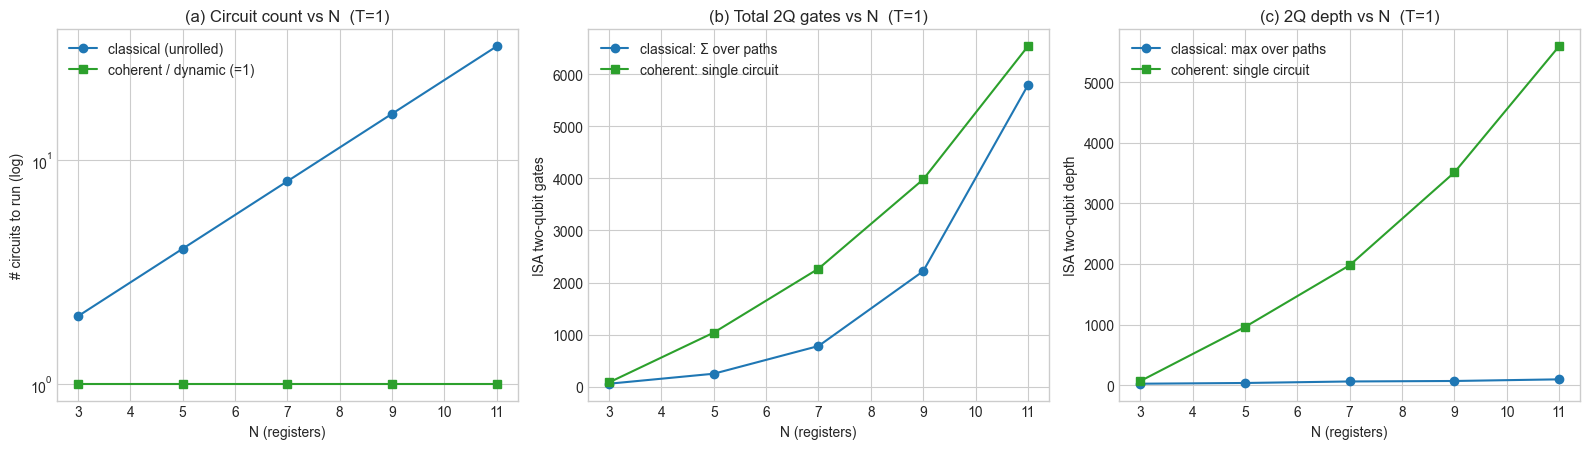

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) circuit count vs N — the headline: classical explodes, coherent stays at 1
ax = axes[0]
ax.semilogy(df_n["N"], df_n["unrolled_circuits"], "o-", color="C0", label="classical (unrolled)")
ax.semilogy(df_n["N"], df_n["coherent_circuits"], "s-", color="C2", label="coherent / dynamic (=1)")
ax.set_xlabel("N (registers)"); ax.set_ylabel("# circuits to run (log)")
ax.set_title("(a) Circuit count vs N  (T=1)"); ax.legend()

# (b) total ISA 2Q gates vs N — breadth (classical) vs depth (coherent)
ax = axes[1]
ax.plot(df_n["N"], df_n["unrolled_2Q_total"], "o-", color="C0", label="classical: Σ over paths")
ax.plot(df_n["N"], df_n["coherent_2Q_total"], "s-", color="C2", label="coherent: single circuit")
ax.set_xlabel("N (registers)"); ax.set_ylabel("ISA two-qubit gates")
ax.set_title("(b) Total 2Q gates vs N  (T=1)"); ax.legend()

# (c) ISA 2Q depth vs N — same comparison as (b), but circuit depth not gate count.
# Classical depth is the max over the paths (they run as separate circuits, so the
# deepest path is what limits coherence); coherent is the single circuit's depth.
ax = axes[2]
ax.plot(df_n["N"], df_n["unrolled_2Q_depth"], "o-", color="C0", label="classical: max over paths")
ax.plot(df_n["N"], df_n["coherent_2Q_depth"], "s-", color="C2", label="coherent: single circuit")
ax.set_xlabel("N (registers)"); ax.set_ylabel("ISA two-qubit depth")
ax.set_title("(c) 2Q depth vs N  (T=1)"); ax.legend()

fig.tight_layout()
out = os.path.join("sandbox", "cswap", "cswap_scaling.png")
fig.savefig(out, dpi=150, bbox_inches="tight")
print("Saved", out)
plt.show()

## Takeaways

- **Classical unrolling trades depth for breadth.** Each path stays shallow — its 2Q depth barely moves
  with `N`, panel (c) — but the number of circuits to transpile/cache/submit grows as `2^((N-1)/2 · T)`,
  panel (a). At `N=11, T=1` that is already 32 circuits; the standard workflow's `find_best_transpilation_*`
  + QPY cache + per-path `build_noisy_batch` all scale with this count.

- **Coherent CSWAP trades breadth for depth.** Always one circuit, but its two-qubit-gate count — panel (b)
  — and two-qubit *depth* — panel (c) — climb steeply with `N`, far above the (essentially flat) classical
  per-circuit depth. (The depth tracks the gate count closely because the multi-controlled Fredkin routing
  is an almost-serial chain with little room for parallelism.) The cost also grows *steeply* with `T` — see
  the **`T`-sweep table** above — because trial `t` becomes a `t`-controlled Fredkin whose decomposition
  explodes (`N=3`: 81 → 10,258 2Q gates from `T=1`→`4`). On today's hardware one very deep circuit
  decoheres, so coherent is attractive at **small `N`/`T`** (exactly the `N=3, T=1` case the comparison
  notebook tests) and loses to unrolling once the multi-controlled routing dominates.

- **Dynamic** is one circuit with no gate blow-up, but pays in mid-circuit measurement + classical
  feed-forward latency and the nested-`if_test` transpiler limitation (`df_t` columns).

**Implication for the workflow.** Coherent CSWAP is most compelling as a *drop-in for the `N=3` (and
maybe `N=5`) end of the standard sweep*, where it erases the path-explosion, QPY cache, and post-selection
logic for the price of one modestly deeper circuit. Beyond that, the depth/gate crossover in panels (b)/(c)
says the unrolled strategy remains the better hardware target — so a hybrid (coherent for small `N`,
unrolled for large `N`) is the natural design.

## Circuit drawings — why the coherent depth scales

The depth blow-up in panel (c) is structural, and the circuits below make it visible (drawn one
decomposition level down, so the swap-test and routing gates show but the figure stays readable).

- **Classical (unrolled)** is one *shallow* static circuit **per path**: swap-tests, a mid-circuit
  measure, and an *unconditional* SWAP routing, done once. Its 2Q depth barely grows with `N` — only the
  *number* of these circuits does.
- **Coherent (CSWAP)** packs *all* routing into a **single** circuit, and every routing gate is
  controlled on the same trial ancilla(s) — so the controlled-SWAPs **cannot run in parallel** and stack
  into one long serial chain (you can see them all hanging off the `trial_a` wire). On top of that, at
  `N=5` the all-pass routing needs **2-controlled Fredkins** (`ccswap`), each of which compiles to several
  times the device 2Q gates of a plain `cswap`. The table below quantifies both effects — together they
  are the depth you see in panel (c).

 N  cswap (1-ctrl Fredkin)  ccswap (2-ctrl Fredkin)  fully-decomposed 2Q gates
 3                       6                        0                         48
 5                       4                        8                        368



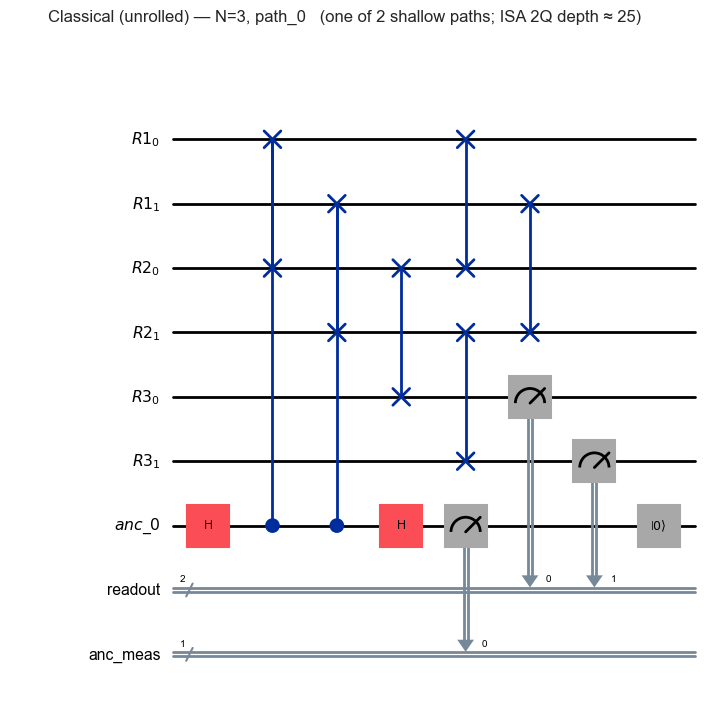

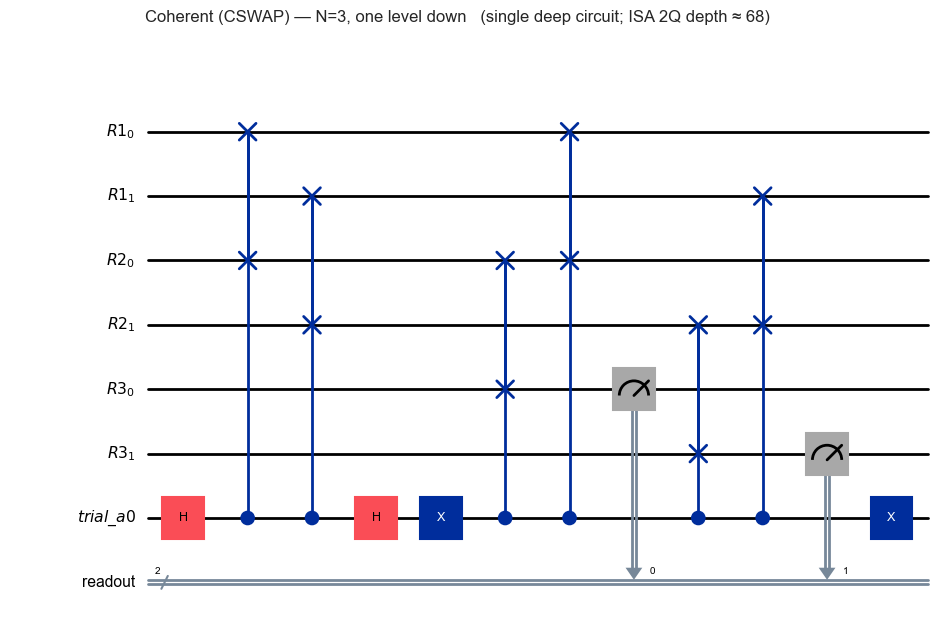

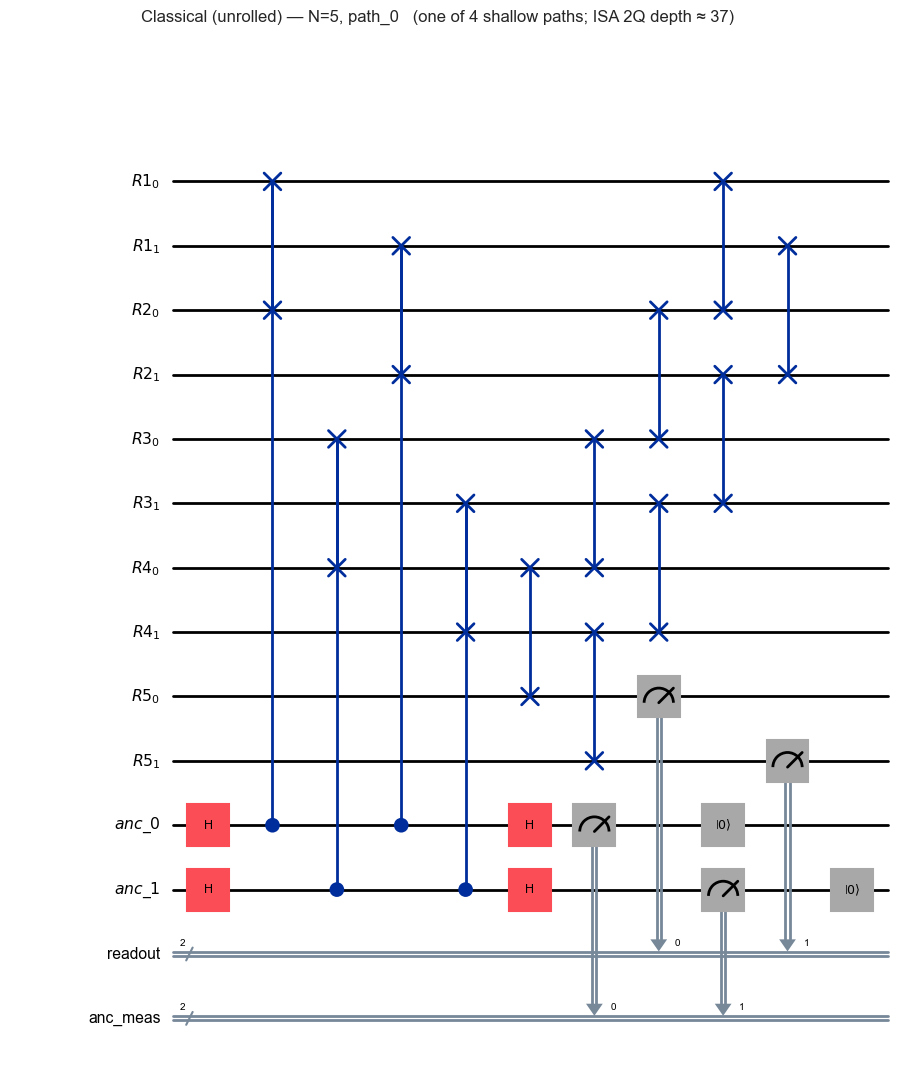

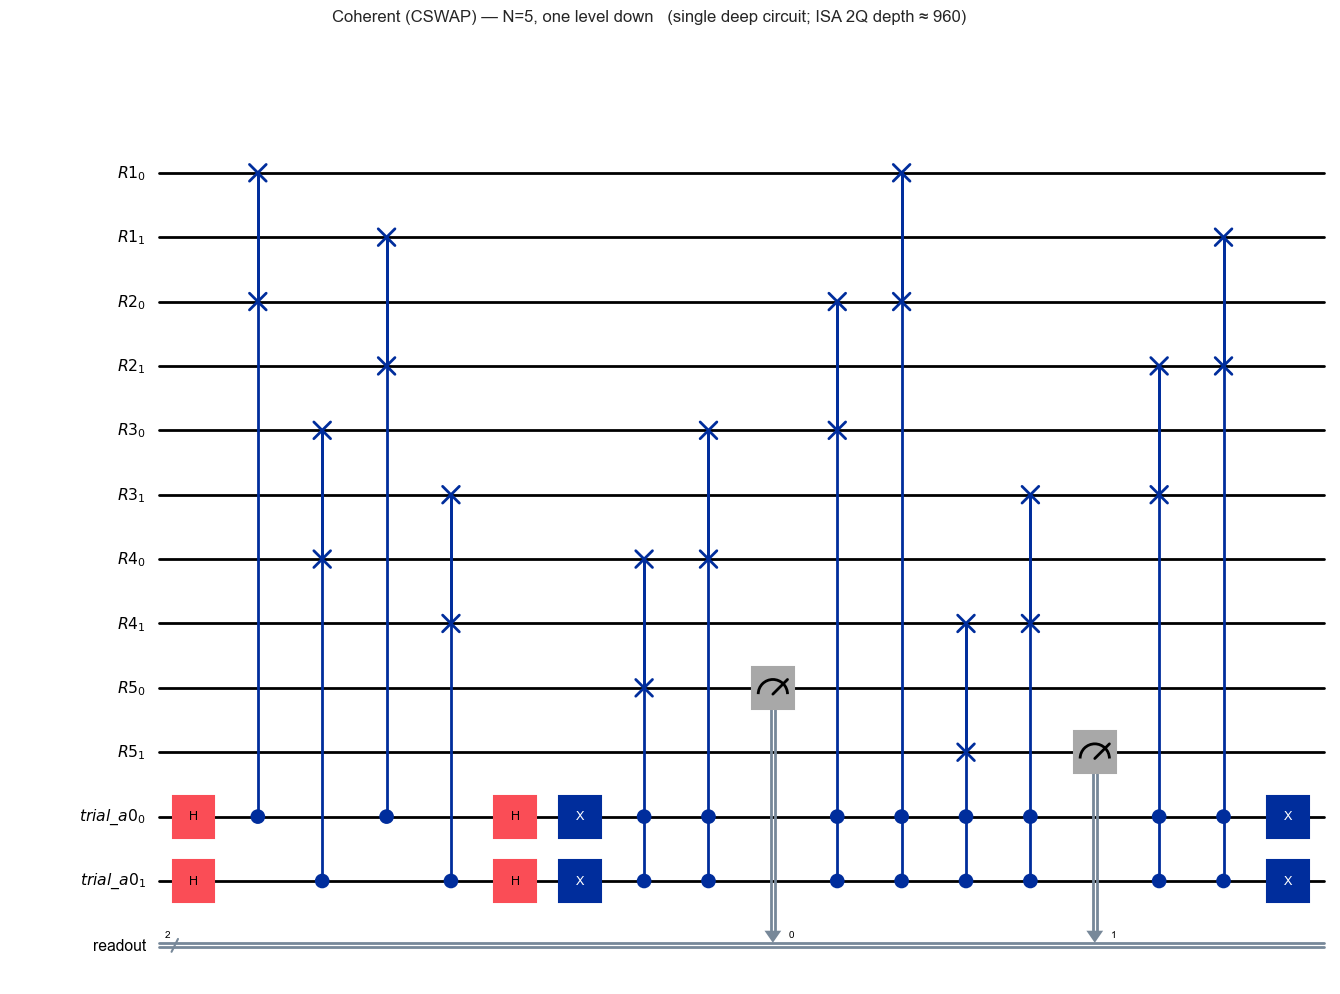

In [8]:
import matplotlib.pyplot as plt
from IPython.display import display

DRAW_N = [3, 5]
draw_dir = os.path.join("sandbox", "cswap")

def _isa_depth(df, n, col):
    return int(df.loc[df["N"] == n, col].iloc[0])

def show_circuit(qc, title, fname, fold=30):
    fig = qc.draw("mpl", fold=fold, idle_wires=False, plot_barriers=False,
                  style={"backgroundcolor": "#FFFFFF", "fontsize": 9})
    fig.suptitle(title, fontsize=12)
    fig.savefig(os.path.join(draw_dir, fname), dpi=140, bbox_inches="tight")
    display(fig)
    plt.close(fig)

# The structural driver, quantified: how many (multi-)controlled Fredkins appear one
# level down, and how many device 2Q gates each coherent circuit becomes when fully
# decomposed (note how one ccswap costs far more than one cswap).
struct = []
for n in DRAW_N:
    one = build_coherent(n, K, 1).decompose()
    full2q = sum(1 for ins in build_coherent(n, K, 1).decompose(reps=3).data if len(ins.qubits) == 2)
    ops = one.count_ops()
    struct.append({"N": n,
                   "cswap (1-ctrl Fredkin)": ops.get("cswap", 0),
                   "ccswap (2-ctrl Fredkin)": ops.get("ccswap", 0),
                   "fully-decomposed 2Q gates": full2q})
print(pd.DataFrame(struct).to_string(index=False))
print()

for n in DRAW_N:
    cl_d  = _isa_depth(df_n, n, "unrolled_2Q_depth")
    coh_d = _isa_depth(df_n, n, "coherent_2Q_depth")
    # classical: one representative unrolled path (logical)
    p0 = build_unrolled(n, K, 1)[0]
    show_circuit(p0,
                 f"Classical (unrolled) — N={n}, path_0   "
                 f"(one of {2 ** ((n - 1) // 2)} shallow paths; ISA 2Q depth ≈ {cl_d})",
                 f"circuit_classical_n{n}.png")
    # coherent: single circuit, one decomposition level (shows the Fredkin routing chain)
    coh = build_coherent(n, K, 1).decompose()
    show_circuit(coh,
                 f"Coherent (CSWAP) — N={n}, one level down   "
                 f"(single deep circuit; ISA 2Q depth ≈ {coh_d})",
                 f"circuit_coherent_n{n}.png")